# Profiler

### Settings

In [1]:
from GraphTacle import Graphtacle
from time import time
import pandas as pd
import numpy as np
import sys
import os
sys.path.append('/home/mik/work/pyntacle/Algorithm/multicore/cython')
from  Algorithm.multicore.cython.wrapper import cython_wrapper_greedy
sys.path.append('/home/mik/work/pyntacle/Algorithm/')
from Algorithm.greedy import call_greedy

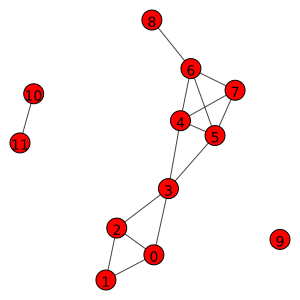

In [19]:
from igraph import Graph, plot

# Define the edge list as tuples (subtract 1 for zero-based indexing)
edge_list = [
    (0, 1), (0, 2), (1, 2), (0, 3), (2, 3), (3, 4), (3, 5),
    (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7), (6, 8),(10,11)
]

# Create the graph
g = Graph(edges=edge_list, directed=False)
g.vs["label"] = [str(i) for i in range(g.vcount())]

# Plot the graph (optional, for visualization)
plot(g, bbox=(300, 300), vertex_label=g.vs["label"])

# g.write_dot("./profiling/graphs/graph_percolation.dot")

In [2]:
inputFile = '/home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list_reduced_1500.tsv'
sep = '\t'
fileType = 'edgelist'
header = True
weighted = True
directed = True
command = 'keyplayer'
outdir = '/home/mik/work/pyntacle/profiling/graphs/string_network/output'
algorithm = "greedy"

mdist = 3


### Reduce STRING dataset

In [8]:
df_edge = pd.read_csv('/home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list.tsv', sep='\t')
df_edge

,protein_1,protein_2,weight
0,9606.ENSP00000000233,9606.ENSP00000356607,17
1,9606.ENSP00000000233,9606.ENSP00000427567,15
2,9606.ENSP00000000233,9606.ENSP00000253413,15
3,9606.ENSP00000000233,9606.ENSP00000493357,47
4,9606.ENSP00000000233,9606.ENSP00000324127,20
...,...,...,...
13715399,9606.ENSP00000501317,9606.ENSP00000475489,19
13715400,9606.ENSP00000501317,9606.ENSP00000370447,15
13715401,9606.ENSP00000501317,9606.ENSP00000312272,22
13715402,9606.ENSP00000501317,9606.ENSP00000402092,16


In [9]:
head = set(df_edge.loc[:, 'protein_1'])
tail = set(df_edge.loc[:, 'protein_2'])
nodes = head.union(tail)
print(f'Number of nodes: {len(nodes)}')

Number of nodes: 19622


In [12]:
selected_nodes = np.random.default_rng().choice(list(nodes), 2000, replace=False)
print(f'Number of selected nodes: {len(selected_nodes)}')

Number of selected nodes: 2000


In [13]:
df_edge_reduced = df_edge[df_edge['protein_1'].isin(selected_nodes) & df_edge['protein_2'].isin(selected_nodes)]
df_edge_reduced.to_csv('/home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list_reduced_2k.tsv', sep='\t', index=False)

test

In [19]:
import igraph as ig
df_edge_reduced = pd.read_csv('/home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list_reduced_100.tsv', sep='\t')

g = ig.Graph.DataFrame(df_edge_reduced, directed=False)
g.simplify(multiple=True, loops=False, combine_edges=max)

print(f'Number of vertices: {g.vcount()}')
print(f'Number of edges: {g.ecount()}')
print(len(g.components()))
print(g.summary())

start = time()
g.shortest_paths(weights=g.es["weight"], mode=ig.ALL)
end = time()
print(f"Passed Time: {end - start}")


Number of vertices: 89
Number of edges: 233
2
IGRAPH UNW- 89 233 -- 
+ attr: name (v), weight (e)
Passed Time: 0.0008008480072021484


### Build Graph

In [3]:
def build_graph(inputFile, command, fileType, sep, header, directed, weighted):
    print(f"\nWorking on: {inputFile}\n")
    g = Graphtacle.from_file(inputFile, command, fileType, sep, header, directed, weighted)
    g.path_function(outdir)


    print(f"Number of nodes: {len(g.vs.indices)}")
    print(f"Number of edges: {len(g.es.indices)}")

    return g

## Keyplayers

### Run - Cython

In [4]:
def run_cython_kp(g, operation, k_size, n_threads):

    start = time()

    k_set, score = cython_wrapper(g, int(k_size), operation, mdist=int(mdist), n_threads=n_threads)
    print(f"Key players: {k_set}")
    print(f"Score: {score}")

    end = time()
    print(f"Passed Time Cython: {end - start}")

    return end - start

### Run - Python

In [5]:
def run_pure_python_kp(g, operation, k_size):		
    start = time()

    kset=call_greedy(g, int(k_size), operation, distance_type=None, mdist=int(mdist))
    print(f"Key players: {kset}")
    end = time()
    print(f"Passed Time pure Python: {end - start}")
    return end - start

### Plot time data

In [6]:
path = '/home/mik/work/pyntacle/profiling/graphs/string_network/'
data_sets = [
    'string_edge_list_reduced_100.tsv',
    'string_edge_list_reduced_500.tsv',
    'string_edge_list_reduced_1k.tsv',
    'string_edge_list_reduced_1500.tsv',
    'string_edge_list_reduced_2k.tsv']

cython_time = []
python_time = []

for inputFile in data_sets:
    graph_path = os.path.join(path, inputFile)
    g = build_graph(graph_path, command, fileType, sep, header, directed, weighted)

    for k in [2, 3, 4]:

        cython_tmp = {'K': k, 'F': 0, 'dF': 0, 'dR': 0, 'mreach': 0, 'nodes': len(g.vs.indices), 'edges': len(g.es.indices)}
        python_tmp = {'K': k, 'F': 0, 'dF': 0, 'dR': 0, 'mreach': 0, 'nodes': len(g.vs.indices), 'edges': len(g.es.indices)}

        for operation in ['F', 'dF', 'dR', 'mreach']:
            
            print(f"Running Cython for {operation} with k={k}")
            cython_tmp[operation] = run_cython_kp(g, operation, k, n_threads=1)

            print(f"Running pure Python for {operation} with k={k}")
            python_tmp[operation] = run_pure_python_kp(g, operation, k)

            print(f"Cython time: {cython_tmp[operation]}, Python time: {python_tmp[operation]}\n")
            

        cython_time.append(cython_tmp)
        python_time.append(python_tmp)
        
    


Working on: /home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list_reduced_100.tsv

Number of nodes: 89
Number of edges: 466
Running Cython for F with k=2
Key players: ['9606.ENSP00000412237', '9606.ENSP00000418915']
Score: 0.133
Passed Time Cython: 0.004517555236816406
Running pure Python for F with k=2
Key players: (['9606.ENSP00000380155', '9606.ENSP00000412237'], 0.133)
Passed Time pure Python: 0.020180463790893555
Cython time: 0.004517555236816406, Python time: 0.020180463790893555

Running Cython for dF with k=2
Key players: ['9606.ENSP00000412237', '9606.ENSP00000418915']
Score: 0.986
Passed Time Cython: 0.3516201972961426
Running pure Python for dF with k=2
Key players: (['9606.ENSP00000412237', '9606.ENSP00000418915'], 0.986)
Passed Time pure Python: 0.3037738800048828
Cython time: 0.3516201972961426, Python time: 0.3037738800048828

Running Cython for dR with k=2
Key players: ['9606.ENSP00000466025', '9606.ENSP00000418915']
Score: 0.034
Passed Time Cython: 

In [8]:
import pickle

with open('/home/mik/work/pyntacle/profiling/graphs/string_network/output/cython_time.pkl', 'wb') as f:
    pickle.dump(cython_time, f)

In [9]:

with open('/home/mik/work/pyntacle/profiling/graphs/string_network/output/python_time.pkl', 'wb') as f:
    pickle.dump(python_time, f)
    

In [ ]:
Working on: /home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list_reduced_100.tsv

Number of nodes: 89
Number of edges: 466
Running Cython for F with k=2
Key players: ['9606.ENSP00000412237', '9606.ENSP00000418915']
Score: 0.133
Passed Time Cython: 0.004517555236816406
Running pure Python for F with k=2
Key players: (['9606.ENSP00000380155', '9606.ENSP00000412237'], 0.133)
Passed Time pure Python: 0.020180463790893555
Cython time: 0.004517555236816406, Python time: 0.020180463790893555

Running Cython for dF with k=2
Key players: ['9606.ENSP00000412237', '9606.ENSP00000418915']
Score: 0.986
Passed Time Cython: 0.3516201972961426
Running pure Python for dF with k=2
Key players: (['9606.ENSP00000412237', '9606.ENSP00000418915'], 0.986)
Passed Time pure Python: 0.3037738800048828
Cython time: 0.3516201972961426, Python time: 0.3037738800048828

Running Cython for dR with k=2
Key players: ['9606.ENSP00000466025', '9606.ENSP00000418915']
Score: 0.034
Passed Time Cython: 0.002214193344116211
Running pure Python for dR with k=2
Key players: (['9606.ENSP00000412237', '9606.ENSP00000418915'], 0.674)
Passed Time pure Python: 0.03331637382507324
Cython time: 0.002214193344116211, Python time: 0.03331637382507324

Running Cython for mreach with k=2
Key players: ['9606.ENSP00000453854', '9606.ENSP00000274458']
Score: 0.0
Passed Time Cython: 0.0017998218536376953
Running pure Python for mreach with k=2
Key players: (['9606.ENSP00000420588', '9606.ENSP00000422097'], 85)
Passed Time pure Python: 0.006272077560424805
Cython time: 0.0017998218536376953, Python time: 0.006272077560424805

Running Cython for F with k=3
Key players: ['9606.ENSP00000418915', '9606.ENSP00000412237', '9606.ENSP00000380155']
Score: 0.178
Passed Time Cython: 0.005139827728271484
Running pure Python for F with k=3
Key players: (['9606.ENSP00000368964', '9606.ENSP00000380155', '9606.ENSP00000412237'], 0.178)
Passed Time pure Python: 0.043616294860839844
Cython time: 0.005139827728271484, Python time: 0.043616294860839844

Running Cython for dF with k=3
Key players: ['9606.ENSP00000419782', '9606.ENSP00000412237', '9606.ENSP00000418915']
Score: 0.987
Passed Time Cython: 0.6327006816864014
Running pure Python for dF with k=3
Key players: (['9606.ENSP00000412237', '9606.ENSP00000418915', '9606.ENSP00000419782'], 0.987)
Passed Time pure Python: 0.6150312423706055
Cython time: 0.6327006816864014, Python time: 0.6150312423706055

Running Cython for dR with k=3
Key players: ['9606.ENSP00000466025', '9606.ENSP00000418915', '9606.ENSP00000412237']
Score: 0.038
Passed Time Cython: 0.0022377967834472656
Running pure Python for dR with k=3
Key players: (['9606.ENSP00000412237', '9606.ENSP00000418915', '9606.ENSP00000466025'], 0.712)
Passed Time pure Python: 0.07280206680297852
Cython time: 0.0022377967834472656, Python time: 0.07280206680297852

Running Cython for mreach with k=3
Key players: ['9606.ENSP00000359871', '9606.ENSP00000276198', '9606.ENSP00000356024']
Score: 0.0
Passed Time Cython: 0.001832723617553711
Running pure Python for mreach with k=3
Key players: (['9606.ENSP00000388137', '9606.ENSP00000420588', '9606.ENSP00000422097'], 85)
Passed Time pure Python: 0.008040189743041992
Cython time: 0.001832723617553711, Python time: 0.008040189743041992

Running Cython for F with k=4
Key players: ['9606.ENSP00000412237', '9606.ENSP00000418915', '9606.ENSP00000368964', '9606.ENSP00000380155']
Score: 0.222
Passed Time Cython: 0.010977506637573242
Running pure Python for F with k=4
Key players: (['9606.ENSP00000368964', '9606.ENSP00000380155', '9606.ENSP00000412237', '9606.ENSP00000418915'], 0.222)
Passed Time pure Python: 0.0748436450958252
Cython time: 0.010977506637573242, Python time: 0.0748436450958252

Running Cython for dF with k=4
Key players: ['9606.ENSP00000419782', '9606.ENSP00000276198', '9606.ENSP00000418915', '9606.ENSP00000412237']
Score: 0.987
Passed Time Cython: 0.9948933124542236
Running pure Python for dF with k=4
Key players: (['9606.ENSP00000276198', '9606.ENSP00000412237', '9606.ENSP00000418915', '9606.ENSP00000419782'], 0.987)
Passed Time pure Python: 1.0458872318267822
Cython time: 0.9948933124542236, Python time: 1.0458872318267822

Running Cython for dR with k=4
Key players: ['9606.ENSP00000412237', '9606.ENSP00000418915', '9606.ENSP00000466025', '9606.ENSP00000483667']
Score: 0.04
Passed Time Cython: 0.002429962158203125
Running pure Python for dR with k=4
Key players: (['9606.ENSP00000349142', '9606.ENSP00000412237', '9606.ENSP00000418915', '9606.ENSP00000466025'], 0.744)
Passed Time pure Python: 0.13963699340820312
Cython time: 0.002429962158203125, Python time: 0.13963699340820312

Running Cython for mreach with k=4
Key players: ['9606.ENSP00000483667', '9606.ENSP00000266556', '9606.ENSP00000301924', '9606.ENSP00000401502']
Score: 0.0
Passed Time Cython: 0.0018787384033203125
Running pure Python for mreach with k=4
Key players: (['9606.ENSP00000380155', '9606.ENSP00000388137', '9606.ENSP00000420588', '9606.ENSP00000422097'], 85)
Passed Time pure Python: 0.021955490112304688
Cython time: 0.0018787384033203125, Python time: 0.021955490112304688


Working on: /home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list_reduced_500.tsv

Number of nodes: 493
Number of edges: 8388
Running Cython for F with k=2
Key players: ['9606.ENSP00000350364', '9606.ENSP00000360162']
Score: 0.008
Passed Time Cython: 0.5287387371063232
Running pure Python for F with k=2
Key players: (['9606.ENSP00000296097', '9606.ENSP00000431076'], 0.008)
Passed Time pure Python: 2.2394542694091797
Cython time: 0.5287387371063232, Python time: 2.2394542694091797

Running Cython for dF with k=2
Key players: ['9606.ENSP00000350364', '9606.ENSP00000360162']
Score: 0.979
Passed Time Cython: 133.34992718696594
Running pure Python for dF with k=2
Key players: (['9606.ENSP00000350364', '9606.ENSP00000360162'], 0.979)
Passed Time pure Python: 100.45008659362793
Cython time: 133.34992718696594, Python time: 100.45008659362793

Running Cython for dR with k=2
Key players: ['9606.ENSP00000285667', '9606.ENSP00000216797']
Score: 0.033
Passed Time Cython: 0.06018853187561035
Running pure Python for dR with k=2
Key players: (['9606.ENSP00000216797', '9606.ENSP00000388107'], 0.62)
Passed Time pure Python: 0.8513569831848145
Cython time: 0.06018853187561035, Python time: 0.8513569831848145

Running Cython for mreach with k=2
Key players: ['9606.ENSP00000290310', '9606.ENSP00000290663']
Score: 0.0
Passed Time Cython: 0.059448957443237305
Running pure Python for mreach with k=2
Key players: (['9606.ENSP00000285667', '9606.ENSP00000327077'], 491)
Passed Time pure Python: 0.13762116432189941
Cython time: 0.059448957443237305, Python time: 0.13762116432189941

Running Cython for F with k=3
Key players: ['9606.ENSP00000350364', '9606.ENSP00000360162', '9606.ENSP00000333660']
Score: 0.012
Passed Time Cython: 1.0522465705871582
Running pure Python for F with k=3
Key players: (['9606.ENSP00000296097', '9606.ENSP00000431076', '9606.ENSP00000446882'], 0.012)
Passed Time pure Python: 4.958440065383911
Cython time: 1.0522465705871582, Python time: 4.958440065383911

Running Cython for dF with k=3
Key players: ['9606.ENSP00000285667', '9606.ENSP00000350364', '9606.ENSP00000360162']
Score: 0.979
Passed Time Cython: 262.46460461616516
Running pure Python for dF with k=3
Key players: (['9606.ENSP00000285667', '9606.ENSP00000350364', '9606.ENSP00000360162'], 0.979)
Passed Time pure Python: 224.45326328277588
Cython time: 262.46460461616516, Python time: 224.45326328277588

Running Cython for dR with k=3
Key players: ['9606.ENSP00000216797', '9606.ENSP00000293831', '9606.ENSP00000285667']
Score: 0.035
Passed Time Cython: 0.06310677528381348
Running pure Python for dR with k=3
Key players: (['9606.ENSP00000216797', '9606.ENSP00000263629', '9606.ENSP00000388107'], 0.656)
Passed Time pure Python: 3.3310372829437256
Cython time: 0.06310677528381348, Python time: 3.3310372829437256

Running Cython for mreach with k=3
Key players: ['9606.ENSP00000346725', '9606.ENSP00000354607', '9606.ENSP00000246081']
Score: 0.0
Passed Time Cython: 0.061036109924316406
Running pure Python for mreach with k=3
Key players: (['9606.ENSP00000278379', '9606.ENSP00000314518', '9606.ENSP00000397151'], 490)
Passed Time pure Python: 0.27316737174987793
Cython time: 0.061036109924316406, Python time: 0.27316737174987793

Running Cython for F with k=4
Key players: ['9606.ENSP00000350364', '9606.ENSP00000360162', '9606.ENSP00000333660', '9606.ENSP00000354227']
Score: 0.016
Passed Time Cython: 1.758331537246704
Running pure Python for F with k=4
Key players: (['9606.ENSP00000296097', '9606.ENSP00000360162', '9606.ENSP00000431076', '9606.ENSP00000446882'], 0.016)
Passed Time pure Python: 8.850126504898071
Cython time: 1.758331537246704, Python time: 8.850126504898071

Running Cython for dF with k=4
Key players: ['9606.ENSP00000431076', '9606.ENSP00000285667', '9606.ENSP00000350364', '9606.ENSP00000360162']
Score: 0.979
Passed Time Cython: 431.8503031730652
Running pure Python for dF with k=4
Key players: (['9606.ENSP00000285667', '9606.ENSP00000350364', '9606.ENSP00000360162', '9606.ENSP00000431076'], 0.979)
Passed Time pure Python: 397.558310508728
Cython time: 431.8503031730652, Python time: 397.558310508728

Running Cython for dR with k=4
Key players: ['9606.ENSP00000285667', '9606.ENSP00000449629', '9606.ENSP00000427514', '9606.ENSP00000293831']
Score: 0.037
Passed Time Cython: 0.07007312774658203
Running pure Python for dR with k=4
Key players: (['9606.ENSP00000216797', '9606.ENSP00000263629', '9606.ENSP00000373979', '9606.ENSP00000388107'], 0.681)
Passed Time pure Python: 4.7470831871032715
Cython time: 0.07007312774658203, Python time: 4.7470831871032715

Running Cython for mreach with k=4
Key players: ['9606.ENSP00000164024', '9606.ENSP00000386043', '9606.ENSP00000494352', '9606.ENSP00000418803']
Score: 0.0
Passed Time Cython: 0.06281733512878418
Running pure Python for mreach with k=4
Key players: (['9606.ENSP00000218089', '9606.ENSP00000262894', '9606.ENSP00000293831', '9606.ENSP00000306662'], 489)
Passed Time pure Python: 0.4299018383026123
Cython time: 0.06281733512878418, Python time: 0.4299018383026123


Working on: /home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list_reduced_1k.tsv

Number of nodes: 996
Number of edges: 35496
Running Cython for F with k=2
Key players: ['9606.ENSP00000356842', '9606.ENSP00000251642']
Score: 0.004
Passed Time Cython: 4.671176433563232
Running pure Python for F with k=2
Key players: (['9606.ENSP00000251642', '9606.ENSP00000440374'], 0.004)
Passed Time pure Python: 19.370864868164062
Cython time: 4.671176433563232, Python time: 19.370864868164062

Running Cython for dF with k=2
Key players: ['9606.ENSP00000380070', '9606.ENSP00000199447']
Score: 0.976
Passed Time Cython: 1728.515480518341
Running pure Python for dF with k=2
Key players: (['9606.ENSP00000199447', '9606.ENSP00000380070'], 0.976)
Passed Time pure Python: 1352.5520000457764
Cython time: 1728.515480518341, Python time: 1352.5520000457764

Running Cython for dR with k=2
Key players: ['9606.ENSP00000199447', '9606.ENSP00000380070']
Score: 0.039
Passed Time Cython: 0.3530855178833008
Running pure Python for dR with k=2
Key players: (['9606.ENSP00000199447', '9606.ENSP00000380070'], 0.777)
Passed Time pure Python: 3.638484239578247
Cython time: 0.3530855178833008, Python time: 3.638484239578247

Running Cython for mreach with k=2
Key players: ['9606.ENSP00000319255', '9606.ENSP00000423777']
Score: 0.0
Passed Time Cython: 0.35315799713134766
Running pure Python for mreach with k=2
Key players: (['9606.ENSP00000368066', '9606.ENSP00000380070'], 994)
Passed Time pure Python: 0.6971344947814941
Cython time: 0.35315799713134766, Python time: 0.6971344947814941

Running Cython for F with k=3
Key players: ['9606.ENSP00000356842', '9606.ENSP00000251642', '9606.ENSP00000199447']
Score: 0.006
Passed Time Cython: 9.40653920173645
Running pure Python for F with k=3
Key players: (['9606.ENSP00000218004', '9606.ENSP00000251642', '9606.ENSP00000440374'], 0.006)
Passed Time pure Python: 43.435855865478516
Cython time: 9.40653920173645, Python time: 43.435855865478516

Running Cython for dF with k=3
Key players: ['9606.ENSP00000295025', '9606.ENSP00000380070', '9606.ENSP00000199447']
Score: 0.976
Passed Time Cython: 3430.5649285316467
Running pure Python for dF with k=3
Key players: (['9606.ENSP00000199447', '9606.ENSP00000295025', '9606.ENSP00000380070'], 0.976)
Passed Time pure Python: 3036.4245944023132
Cython time: 3430.5649285316467, Python time: 3036.4245944023132

Running Cython for dR with k=3
Key players: ['9606.ENSP00000199447', '9606.ENSP00000380070', '9606.ENSP00000358548']
Score: 0.041
Passed Time Cython: 0.3719172477722168
Running pure Python for dR with k=3
Key players: (['9606.ENSP00000199447', '9606.ENSP00000358548', '9606.ENSP00000380070'], 0.796)
Passed Time pure Python: 9.80060625076294
Cython time: 0.3719172477722168, Python time: 9.80060625076294

Running Cython for mreach with k=3
Key players: ['9606.ENSP00000269143', '9606.ENSP00000394394', '9606.ENSP00000296921']
Score: 0.0
Passed Time Cython: 0.3558976650238037
Running pure Python for mreach with k=3
Key players: (['9606.ENSP00000239451', '9606.ENSP00000370126', '9606.ENSP00000380070'], 993)
Passed Time pure Python: 1.3599166870117188
Cython time: 0.3558976650238037, Python time: 1.3599166870117188

Running Cython for F with k=4
Key players: ['9606.ENSP00000356842', '9606.ENSP00000251642', '9606.ENSP00000199447', '9606.ENSP00000295025']
Score: 0.008
Passed Time Cython: 15.422736167907715
Running pure Python for F with k=4
Key players: (['9606.ENSP00000218004', '9606.ENSP00000251642', '9606.ENSP00000315554', '9606.ENSP00000440374'], 0.008)
Passed Time pure Python: 77.12711119651794
Cython time: 15.422736167907715, Python time: 77.12711119651794

Running Cython for dF with k=4
Key players: ['9606.ENSP00000199447', '9606.ENSP00000295025', '9606.ENSP00000361021', '9606.ENSP00000380070']
Score: 0.976
Passed Time Cython: 5670.841816186905
Running pure Python for dF with k=4
Key players: (['9606.ENSP00000199447', '9606.ENSP00000295025', '9606.ENSP00000361021', '9606.ENSP00000380070'], 0.976)
Passed Time pure Python: 5297.818143367767
Cython time: 5670.841816186905, Python time: 5297.818143367767

Running Cython for dR with k=4
Key players: ['9606.ENSP00000358548', '9606.ENSP00000199447', '9606.ENSP00000361021', '9606.ENSP00000380070']
Score: 0.043
Passed Time Cython: 0.3954892158508301
Running pure Python for dR with k=4
Key players: (['9606.ENSP00000199447', '9606.ENSP00000358548', '9606.ENSP00000380070', '9606.ENSP00000497641'], 0.81)
Passed Time pure Python: 20.326026439666748
Cython time: 0.3954892158508301, Python time: 20.326026439666748

Running Cython for mreach with k=4
Key players: ['9606.ENSP00000301825', '9606.ENSP00000222800', '9606.ENSP00000359444', '9606.ENSP00000331209']
Score: 0.0
Passed Time Cython: 0.3577728271484375
Running pure Python for mreach with k=4
Key players: (['9606.ENSP00000363142', '9606.ENSP00000372295', '9606.ENSP00000380070', '9606.ENSP00000399979'], 992)
Passed Time pure Python: 2.1953158378601074
Cython time: 0.3577728271484375, Python time: 2.1953158378601074


Working on: /home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list_reduced_1500.tsv

Number of nodes: 1492
Number of edges: 83918
Running Cython for F with k=2
Key players: ['9606.ENSP00000484095', '9606.ENSP00000358460']
Score: 0.003
Passed Time Cython: 16.28454852104187
Running pure Python for F with k=2
Key players: (['9606.ENSP00000358460', '9606.ENSP00000484095'], 0.003)
Passed Time pure Python: 71.07998061180115
Cython time: 16.28454852104187, Python time: 71.07998061180115

Running Cython for dF with k=2
Key players: ['9606.ENSP00000265191', '9606.ENSP00000356530']
Score: 0.974
Passed Time Cython: 8456.503070116043
Running pure Python for dF with k=2
Key players: (['9606.ENSP00000265191', '9606.ENSP00000356530'], 0.974)
Passed Time pure Python: 6722.312159538269
Cython time: 8456.503070116043, Python time: 6722.312159538269

Running Cython for dR with k=2
Key players: ['9606.ENSP00000265191', '9606.ENSP00000356530']
Score: 0.037
Passed Time Cython: 1.1270902156829834
Running pure Python for dR with k=2
Key players: (['9606.ENSP00000229135', '9606.ENSP00000449328'], 0.661)
Passed Time pure Python: 8.6092050075531
Cython time: 1.1270902156829834, Python time: 8.6092050075531

Running Cython for mreach with k=2
Key players: ['9606.ENSP00000252250', '9606.ENSP00000484658']
Score: 0.0
Passed Time Cython: 1.0987484455108643
Running pure Python for mreach with k=2
Key players: (['9606.ENSP00000244534', '9606.ENSP00000301364'], 1490)
Passed Time pure Python: 1.8463830947875977
Cython time: 1.0987484455108643, Python time: 1.8463830947875977

Running Cython for F with k=3
Key players: ['9606.ENSP00000484095', '9606.ENSP00000358460', '9606.ENSP00000380605']
Score: 0.004
Passed Time Cython: 33.08517813682556
Running pure Python for F with k=3
Key players: (['9606.ENSP00000358460', '9606.ENSP00000380605', '9606.ENSP00000484095'], 0.004)
Passed Time pure Python: 158.3587245941162
Cython time: 33.08517813682556, Python time: 158.3587245941162

Running Cython for dF with k=3
Key players: ['9606.ENSP00000234831', '9606.ENSP00000356530', '9606.ENSP00000265191']
Score: 0.975
Passed Time Cython: 16783.413676977158
Running pure Python for dF with k=3
Key players: (['9606.ENSP00000234831', '9606.ENSP00000265191', '9606.ENSP00000356530'], 0.975)
Passed Time pure Python: 15081.83898115158
Cython time: 16783.413676977158, Python time: 15081.83898115158

Running Cython for dR with k=3
Key players: ['9606.ENSP00000257904', '9606.ENSP00000265191', '9606.ENSP00000356530']
Score: 0.039
Passed Time Cython: 1.4207963943481445
Running pure Python for dR with k=3
Key players: (['9606.ENSP00000229135', '9606.ENSP00000356530', '9606.ENSP00000449328'], 0.707)
Passed Time pure Python: 32.924906492233276
Cython time: 1.4207963943481445, Python time: 32.924906492233276

Running Cython for mreach with k=3
Key players: ['9606.ENSP00000257696', '9606.ENSP00000409924', '9606.ENSP00000495413']
Score: 0.0
Passed Time Cython: 1.0872836112976074
Running pure Python for mreach with k=3
Key players: (['9606.ENSP00000363593', '9606.ENSP00000296135', '9606.ENSP00000388566'], 1489)
Passed Time pure Python: 2.145620346069336
Cython time: 1.0872836112976074, Python time: 2.145620346069336

Running Cython for F with k=4
Key players: ['9606.ENSP00000484095', '9606.ENSP00000358460', '9606.ENSP00000380605', '9606.ENSP00000485484']
Score: 0.004
Passed Time Cython: 42.346123456954956
Running pure Python for F with k=4
Key players: (['9606.ENSP00000358460', '9606.ENSP00000380605', '9606.ENSP00000484095', '9606.ENSP00000490139'], 0.004)
Passed Time pure Python: 214.68557786941528
Cython time: 42.346123456954956, Python time: 214.68557786941528

Running Cython for dF with k=4
Key players: ['9606.ENSP00000418734', '9606.ENSP00000265191', '9606.ENSP00000234831', '9606.ENSP00000356530']
Score: 0.975
Passed Time Cython: 27926.209528923035
Running pure Python for dF with k=4
Key players: (['9606.ENSP00000234831', '9606.ENSP00000265191', '9606.ENSP00000356530', '9606.ENSP00000418734'], 0.975)
Passed Time pure Python: 26206.422688007355
Cython time: 27926.209528923035, Python time: 26206.422688007355

Running Cython for dR with k=4
Key players: ['9606.ENSP00000356530', '9606.ENSP00000284981', '9606.ENSP00000265191', '9606.ENSP00000262715']
Score: 0.041
Passed Time Cython: 1.4116241931915283
Running pure Python for dR with k=4
Key players: (['9606.ENSP00000229135', '9606.ENSP00000265191', '9606.ENSP00000356530', '9606.ENSP00000449328'], 0.741)
Passed Time pure Python: 65.12236523628235
Cython time: 1.4116241931915283, Python time: 65.12236523628235

Running Cython for mreach with k=4
Key players: ['9606.ENSP00000292879', '9606.ENSP00000366032', '9606.ENSP00000274547', '9606.ENSP00000496416']
Score: 0.0
Passed Time Cython: 1.119232416152954
Running pure Python for mreach with k=4
Key players: (['9606.ENSP00000418754', '9606.ENSP00000377370', '9606.ENSP00000316924', '9606.ENSP00000274547'], 1488)
Passed Time pure Python: 3.2636566162109375
Cython time: 1.119232416152954, Python time: 3.2636566162109375


Working on: /home/mik/work/pyntacle/profiling/graphs/string_network/string_edge_list_reduced_2k.tsv

Number of nodes: 1996
Number of edges: 142562
Running Cython for F with k=2
Key players: ['9606.ENSP00000260128', '9606.ENSP00000433277']
Score: 0.004
Passed Time Cython: 42.11296820640564
Running pure Python for F with k=2
Key players: (['9606.ENSP00000260128', '9606.ENSP00000312262'], 0.004)
Passed Time pure Python: 172.21006870269775
Cython time: 42.11296820640564, Python time: 172.21006870269775

Running Cython for dF with k=2
Key players: ['9606.ENSP00000260128', '9606.ENSP00000451828']
Score: 0.974
Passed Time Cython: 24457.14315342903
Running pure Python for dF with k=2
Key players: (['9606.ENSP00000260128', '9606.ENSP00000451828'], 0.974)
Passed Time pure Python: 20728.633336782455
Cython time: 24457.14315342903, Python time: 20728.633336782455

Running Cython for dR with k=2
Key players: ['9606.ENSP00000451828', '9606.ENSP00000418734']
Score: 0.038
Passed Time Cython: 2.6028294563293457
Running pure Python for dR with k=2
Key players: (['9606.ENSP00000418734', '9606.ENSP00000451828'], 0.729)
Passed Time pure Python: 16.361716747283936
Cython time: 2.6028294563293457, Python time: 16.361716747283936

Running Cython for mreach with k=2
Key players: ['9606.ENSP00000351937', '9606.ENSP00000242480']
Score: 0.0
Passed Time Cython: 2.4170336723327637
Running pure Python for mreach with k=2
Key players: (['9606.ENSP00000264498', '9606.ENSP00000357810'], 1994)
Passed Time pure Python: 3.70801043510437
Cython time: 2.4170336723327637, Python time: 3.70801043510437

Running Cython for F with k=3
Key players: ['9606.ENSP00000260128', '9606.ENSP00000433277', '9606.ENSP00000467041']
Score: 0.005
Passed Time Cython: 90.3175597190857
Running pure Python for F with k=3
Key players: (['9606.ENSP00000260128', '9606.ENSP00000312262', '9606.ENSP00000471613'], 0.005)
Passed Time pure Python: 416.2846851348877
Cython time: 90.3175597190857, Python time: 416.2846851348877

Running Cython for dF with k=3
Key players: ['9606.ENSP00000418734', '9606.ENSP00000451828', '9606.ENSP00000260128']
Score: 0.974
Passed Time Cython: 49730.535482645035
Running pure Python for dF with k=3
Key players: (['9606.ENSP00000260128', '9606.ENSP00000418734', '9606.ENSP00000451828'], 0.974)
Passed Time pure Python: 45319.39334797859
Cython time: 49730.535482645035, Python time: 45319.39334797859

Running Cython for dR with k=3
Key players: ['9606.ENSP00000451828', '9606.ENSP00000497733', '9606.ENSP00000418734']
Score: 0.04
Passed Time Cython: 2.6478803157806396
Running pure Python for dR with k=3
Key players: (['9606.ENSP00000053468', '9606.ENSP00000418734', '9606.ENSP00000451828'], 0.762)
Passed Time pure Python: 42.72087645530701
Cython time: 2.6478803157806396, Python time: 42.72087645530701

Running Cython for mreach with k=3
Key players: ['9606.ENSP00000471700', '9606.ENSP00000279387', '9606.ENSP00000299084']
Score: 0.0
Passed Time Cython: 2.4877610206604004
Running pure Python for mreach with k=3
Key players: (['9606.ENSP00000264498', '9606.ENSP00000293777', '9606.ENSP00000331823'], 1993)
Passed Time pure Python: 7.105186700820923
Cython time: 2.4877610206604004, Python time: 7.105186700820923

Running Cython for F with k=4
Key players: ['9606.ENSP00000260128', '9606.ENSP00000433277', '9606.ENSP00000467041', '9606.ENSP00000312262']
Score: 0.006
Passed Time Cython: 143.91132640838623
Running pure Python for F with k=4
Key players: (['9606.ENSP00000260128', '9606.ENSP00000312262', '9606.ENSP00000433277', '9606.ENSP00000471613'], 0.006)
Passed Time pure Python: 704.0830342769623
Cython time: 143.91132640838623, Python time: 704.0830342769623

Running Cython for dF with k=4
Key players: ['9606.ENSP00000497733', '9606.ENSP00000260128', '9606.ENSP00000418734', '9606.ENSP00000451828']
Score: 0.974
Passed Time Cython: 82511.48404121399
Running pure Python for dF with k=4
Key players: (['9606.ENSP00000260128', '9606.ENSP00000418734', '9606.ENSP00000451828', '9606.ENSP00000497733'], 0.974)
Passed Time pure Python: 81034.22289466858
Cython time: 82511.48404121399, Python time: 81034.22289466858

Running Cython for dR with k=4
Key players: ['9606.ENSP00000324806', '9606.ENSP00000418734', '9606.ENSP00000497733', '9606.ENSP00000451828']
Score: 0.042
Passed Time Cython: 3.429431200027466
Running pure Python for dR with k=4
Key players: (['9606.ENSP00000053468', '9606.ENSP00000160382', '9606.ENSP00000418734', '9606.ENSP00000451828'], 0.783)
Passed Time pure Python: 98.8158802986145
Cython time: 3.429431200027466, Python time: 98.8158802986145

Running Cython for mreach with k=4
Key players: ['9606.ENSP00000405482', '9606.ENSP00000358217', '9606.ENSP00000355800', '9606.ENSP00000333640']
Score: 0.0
Passed Time Cython: 2.830056667327881
Running pure Python for mreach with k=4
Key players: (['9606.ENSP00000264498', '9606.ENSP00000264952', '9606.ENSP00000322088', '9606.ENSP00000458762'], 1992)
Passed Time pure Python: 12.503011703491211
Cython time: 2.830056667327881, Python time: 12.503011703491211

# Instructions for compilation

export IGRAPH_PREFIX=$PWD/third_party/igraph

mkdir -p build && cd build

cmake .. \
  -DCMAKE_BUILD_TYPE=Release \
  -DCMAKE_INSTALL_PREFIX=${IGRAPH_PREFIX} \
  -DCMAKE_POSITION_INDEPENDENT_CODE=ON  # <-- This is the fix

cmake --build .          # Build everything
cmake --install .        # “Install” into $IGRAPH_PREFIX

cd ..
